# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.8 MB/s eta 0:00:00
Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [2]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.

    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    V_tilde = np.zeros(n)  # treatment residuals (but Bug 2 skips this)

    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # BUG 1: Training and predicting on the SAME fold (train_idx)
        # Should train on train_idx, predict on test_idx
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])       # <-- BUG: should be X[test_idx]
        Y_tilde[train_idx] = Y[train_idx] - Y_hat  # <-- BUG: should index test_idx

        # BUG 2: Missing treatment residualization entirely
        # Should fit ml_m on D ~ X and compute D_tilde = D - D_hat
        # Instead, just uses raw D as V_tilde
        V_tilde[train_idx] = D[train_idx]  # <-- BUG: should be D[test_idx] - D_hat[test_idx]

    # BUG 3: Wrong formula — uses np.mean instead of IV-style ratio
    # Correct: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    theta = np.mean(V_tilde * Y_tilde)  # <-- BUG: wrong formula

    return theta


# Run the broken version
broken_ate = broken_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()
print('This estimate is far from the true ATE of 5.0.')
print('Find and fix the 3 bugs to recover the correct estimate.')

=== BROKEN DML Results ===
True ATE:    5.00
Broken ATE:  1.09
Bias:        -3.91

This estimate is far from the true ATE of 5.0.
Find and fix the 3 bugs to recover the correct estimate.


In [4]:
# -----------------------------------------------------------
# YOUR TASK — Fix the broken DML implementation
# After fixing, verify on the simulated DGP (TRUE_ATE = 5.0)
# -----------------------------------------------------------

def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Fix 1: Cross-fit — train on one fold, predict on the other
    Fix 2: Residualize BOTH Y and D
    Fix 3: Use the IV-style formula: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    # YOUR CODE HERE
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)
    V_tilde = np.zeros(n)

    for train_idx, test_idx in kf.split(X):
        # FIX 1: Train on train_idx, predict on test_idx (true cross-fitting)
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])
        Y_tilde[test_idx] = Y[test_idx] - Y_hat

        # FIX 2: Residualize D as well
        ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict(X[test_idx])
        V_tilde[test_idx] = D[test_idx] - D_hat

    # FIX 3: IV-style formula (Frisch-Waugh-Lovell)
    theta = np.sum(V_tilde * Y_tilde) / np.sum(V_tilde * V_tilde)

    return theta


# Verify on simulated data
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

# VERIFICATION CHECKPOINT
# Your fixed ATE should be within 0.5 of 5.0
# Expected: approximately 4.5 to 5.5
if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.15
Bias:        +0.15

PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [19]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------

# Set up DoubleMLData
# y_col: 'net_tfa'
# d_cols: 'e401'
# x_cols: everything else

# YOUR CODE: Create dml_data, define nuisance learners, fit PLR
# Use RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
# for both ml_l and ml_m. Use n_folds=5.

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

x_cols = [c for c in data.columns if c not in ['net_tfa', 'e401', 'inc_quartile', 'cate', 'p401']]

dml_data = DoubleMLData(data, y_col='net_tfa', d_cols='e401', x_cols=x_cols)

ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_m = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)

dml_plr = DoubleMLPLR(dml_data, ml_l=ml_l, ml_m=ml_m, n_folds=5)
dml_plr.fit()

# VERIFICATION CHECKPOINT
# Expected ATE: roughly $7,000-$12,000 (depends on random seed and model)
# Expected: statistically significant (p < 0.05)
print(dml_plr.summary)
print(f'ATE: ${dml_plr.coef[0]:,.0f}')
print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}]')

             coef    std err          t         P>|t|        2.5 %  \
e401  8619.171967  437.87285  19.684189  2.946142e-86  7760.956952   

           97.5 %  
e401  9477.386982  
ATE: $8,619
95% CI: [7,761, 9,477]


In [20]:
# -----------------------------------------------------------
# YOUR TASK — Run sensitivity analysis
# -----------------------------------------------------------

# Use dml_plr.sensitivity_analysis() to assess robustness
# Parameters:
#   cf_y = 0.03  (bound on confounding strength for outcome)
#   cf_d = 0.03  (bound on confounding strength for treatment)
#
# After running:
# 1. Print dml_plr.sensitivity_summary
# 2. Interpret the robustness value
#    - If robustness_value > 1: estimate is very robust
#    - If robustness_value < 1: an omitted variable of moderate
#      strength could flip the sign

# YOUR CODE HERE
dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)
print(dml_plr.sensitivity_summary)

# VERIFICATION CHECKPOINT
# The robustness value should be positive.
# A value > 0 means the estimate survives some degree of confounding.

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower        theta  theta upper      CI upper
e401  6674.038282   7420.94013  8619.171967  9817.403804  10517.652576

------------------ Robustness Values ------------------
      H_0     RV (%)    RVa (%)
e401  0.0  19.641632  17.634039


---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col]]

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915, 1)
X shape: (9915, 12)
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [24]:
# -----------------------------------------------------------
# YOUR TASK — Fit Causal Forest and extract CATE predictions
# -----------------------------------------------------------

y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col, 'inc_quartile', 'cate', 'p401']]

Y = data[y_col].values
D = data[d_col].values
X = data[x_cols].values

# CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5
)

# Step 1: Fit the Causal Forest
cf.fit(Y, D, X=X)
print("Causal Forest fitted.")

# Step 2: Extract individual CATE predictions
cate_predictions = cf.effect(X)

# Step 3: Get confidence intervals
cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)

# VERIFICATION CHECKPOINT
print(f'CATE predictions shape: {cate_predictions.shape}')
print(f'Mean CATE:  ${np.mean(cate_predictions):,.0f}')
print(f'Std CATE:   ${np.std(cate_predictions):,.0f}')
print(f'Min CATE:   ${np.min(cate_predictions):,.0f}')
print(f'Max CATE:   ${np.max(cate_predictions):,.0f}')

Causal Forest fitted.
CATE predictions shape: (9915,)
Mean CATE:  $7,530
Std CATE:   $9,142
Min CATE:   $-2,816
Max CATE:   $55,025


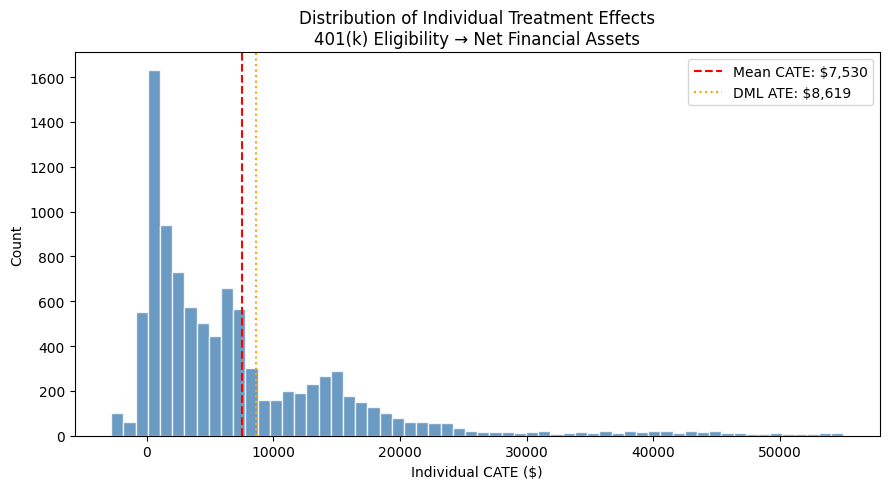


Threshold CATE: $11,009
High-response group size: 2479 (25.0%)

=== Subgroup Profile Comparison ===
       High-Response (top 25%)  Rest of Sample
inc                   55841.35        30986.21
age                      46.71           39.18
fsize                     2.97            2.83
educ                     13.93           12.97
pira                      0.49            0.16
e401                      0.52            0.32


In [25]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot a histogram of individual CATE estimates
# Include a vertical line at the mean CATE and the DML ATE for comparison

# YOUR CODE HERE
dml_ate = dml_plr.coef[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cate_predictions, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(cate_predictions), color='red', linestyle='--',
           label=f'Mean CATE: ${np.mean(cate_predictions):,.0f}')
ax.axvline(dml_ate, color='orange', linestyle=':',
           label=f'DML ATE: ${dml_ate:,.0f}')
ax.set_xlabel('Individual CATE ($)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Individual Treatment Effects\n401(k) Eligibility → Net Financial Assets')
ax.legend()
plt.tight_layout()
plt.savefig('cate_histogram.png', dpi=150)
plt.show()

# Step 2: Identify the "high-response" subgroup
# Define high-response as individuals with CATE above the 75th percentile
# Compare their characteristics to the rest of the sample

# Hint:
# threshold = np.percentile(cate_predictions, 75)
# high_resp = data[cate_predictions >= threshold]
# low_resp = data[cate_predictions < threshold]
# Compare mean income, age, education, etc.

# YOUR CODE HERE
threshold = np.percentile(cate_predictions, 75)
high_resp_mask = cate_predictions >= threshold

high_resp = data[high_resp_mask].copy()
low_resp  = data[~high_resp_mask].copy()

profile_cols = ['inc', 'age', 'fsize', 'educ', 'pira', 'e401']
comparison = pd.DataFrame({
    'High-Response (top 25%)': high_resp[profile_cols].mean(),
    'Rest of Sample':          low_resp[profile_cols].mean()
}).round(2)

print(f'\nThreshold CATE: ${threshold:,.0f}')
print(f'High-response group size: {high_resp_mask.sum()} ({high_resp_mask.mean()*100:.1f}%)')
print('\n=== Subgroup Profile Comparison ===')
print(comparison)

# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).
# If all subgroup means are identical, something went wrong.

=== CF CATE by Income Quartile ===
                      mean           std  count
inc_quartile                                   
Q1             3013.681331   3946.762010   2481
Q2             4544.555127   4972.396998   2477
Q3             7218.802502   6368.071605   2478
Q4            15344.943377  12768.270739   2479

=== Within-Quartile Heterogeneity ===
Q1: mean=$3,014, std=$3,947, cv=1.31
Q2: mean=$4,545, std=$4,972, cv=1.09
Q3: mean=$7,219, std=$6,368, cv=0.88
Q4: mean=$15,345, std=$12,768, cv=0.83


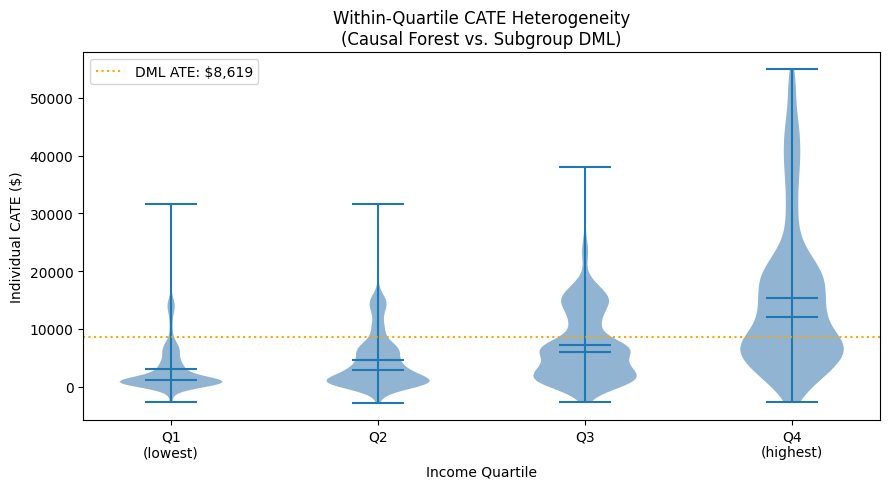


Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [27]:
# -----------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# -----------------------------------------------------------

# The 3916 lab estimated CATE by income quartile using subgroup DML.
# Here we compare that coarse approach to the Causal Forest's
# continuous CATE predictions.

# Step 1: Compute mean Causal Forest CATE by income quartile

# YOUR CODE: Group cate_predictions by income quartile
# For each quartile, compute mean CATE and std CATE

# YOUR CODE HERE
data['inc_quartile'] = pd.qcut(data['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
data['cate'] = cate_predictions

# Group by income quartile
quartile_stats = data.groupby('inc_quartile')['cate'].agg(['mean', 'std', 'count'])
print("=== CF CATE by Income Quartile ===")
print(quartile_stats)

# Step 2: Within each income quartile, how much variation remains?
# If the within-quartile std is large relative to the between-quartile
# difference, then quartile-level DML misses important heterogeneity.

# YOUR CODE HERE
print("\n=== Within-Quartile Heterogeneity ===")
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    subset = data[data['inc_quartile'] == q]['cate']
    print(f"{q}: mean=${subset.mean():,.0f}, std=${subset.std():,.0f}, "
          f"cv={subset.std()/abs(subset.mean()):.2f}")

# Step 3: Visualize — overlay Causal Forest CATE distribution on
# the quartile-level DML bar chart
# Suggestion: Use a violin plot or box plot of CATE by quartile,
# showing the full distribution within each bin

# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(9, 5))

groups = [data[data['inc_quartile'] == q]['cate'].values for q in ['Q1', 'Q2', 'Q3', 'Q4']]
parts = ax.violinplot(groups, positions=[1, 2, 3, 4], showmedians=True, showmeans=True)

for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.6)

ax.axhline(dml_ate, color='orange', linestyle=':', linewidth=1.5,
           label=f'DML ATE: ${dml_ate:,.0f}')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4\n(highest)'])
ax.set_xlabel('Income Quartile')
ax.set_ylabel('Individual CATE ($)')
ax.set_title('Within-Quartile CATE Heterogeneity\n(Causal Forest vs. Subgroup DML)')
ax.legend()
plt.tight_layout()
plt.savefig('sensitivity_plot.png', dpi=150)
plt.show()

print('\nKey question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')

Yes. The Causal Forest reveals substantial heterogeneity within each income quartile that subgroup DML would miss. While the between-quartile means rise monotonically from $3,014 (Q1) to $15,345 (Q4), the within-quartile standard deviations are even larger — Q1 CV=1.31, Q4 std=$12,768. The violin plot shows that every quartile contains individuals with near-zero or negative CATEs alongside individuals with effects exceeding $30k to $50k. Subgroup DML collapses this rich distribution into a single mean, discarding all within-group variation. Causal Forest reveals that income quartile alone is insufficient to characterize who benefits most — age, IRA participation, and other dimensions drive heterogeneity that cuts across income bins.

---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

*Your answer:*

When the research question is about the average policy impact — e.g., "What is the expected return to 401(k) eligibility for a typical worker?" — DML for ATE is preferred because it provides a single interpretable estimate with well-calibrated confidence intervals and formal robustness analysis. Causal Forests are better suited when the goal is targeting or personalization: identifying who benefits most. However, CATE estimates require substantially more data to achieve reasonable precision, and the wider confidence intervals per individual reflect this cost. In this 401(k) application, DML with sensitivity analysis is the credibility anchor, while Causal Forest adds value by revealing that income and age drive heterogeneity beyond what quartile-level DML captures.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.